In [70]:
import pandas as pd
import sqlite3

df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

conn = sqlite3.connect(':memory:')
df.to_sql('customer_behavior', conn, index=False)

def run_query(sql_code):
    return pd.read_sql_query(sql_code, conn)

print(" Total baris:", len(df))

 Total baris: 350


In [60]:
check_first="""
SELECT * FROM customer_behavior LIMIT 5;
"""
run_query(check_first)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,1,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,0,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,1,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,0,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,1,55,Unsatisfied


In [29]:
unique_customer="""
SELECT COUNT(DISTINCT "Customer ID") as unique_customer FROM customer_behavior
;
"""
run_query(unique_customer)

,unique_customer
0,350


In [30]:
stats_spend_days="""
SELECT
  AVG("Total Spend") as average_spend,
  MIN("Total Spend") as min_spend,
  MAX("Total Spend") as max_spend,
  AVG("Days Since Last Purchase") as average_days,
  MIN("Days Since Last Purchase") as min_days,
  MAX("Days Since Last Purchase") as max_days
from customer_behavior
;
"""
run_query(stats_spend_days)

,average_spend,min_spend,max_spend,average_days,min_days,max_days
0,845.381714,410.8,1520.1,26.588571,9,63


In [55]:
segment_customer="""
with segment_customer as (
    SELECT
    *,
    case
      when "Days Since Last Purchase" > 0 AND "Days Since Last Purchase" <= 30 THEN 'Active User'
      when "Days Since Last Purchase" > 30 AND "Days Since Last Purchase" <= 45 THEN 'At-Risk User'
      when "Days Since Last Purchase" > 45 THEN 'Churned Customer'
    end as segment
    from customer_behavior
)
SELECT
  segment,
  COUNT(DISTINCT "Customer ID") as unique_customer,
  round(AVG("Total Spend"),2) as average_spend
from segment_customer
group by segment
;
"""
run_query(segment_customer)

,segment,unique_customer,average_spend
0,Active User,226,969.30
1,At-Risk User,83,595.26
2,Churned Customer,41,668.64


In [71]:
segment_customer="""
with segment_customer as (
    SELECT
    *,
    case
      when "Days Since Last Purchase" > 0 AND "Days Since Last Purchase" <= 30 THEN 'Active User'
      when "Days Since Last Purchase" > 30 AND "Days Since Last Purchase" <= 45 THEN 'At-Risk User'
      when "Days Since Last Purchase" > 45 THEN 'Churned Customer'
    end as segment
    from customer_behavior
)
SELECT
  "Membership Type",
  segment,
  COUNT(DISTINCT "Customer ID") as unique_customer,
  round(AVG("Total Spend"),2) as average_spend
from segment_customer
group by "Membership Type", segment
;
"""
run_query(segment_customer)

,Membership Type,segment,unique_customer,average_spend
0,Bronze,Active User,56,447.11
1,Bronze,At-Risk User,53,497.85
2,Bronze,Churned Customer,7,498.39
3,Gold,Active User,111,1319.82
4,Gold,At-Risk User,6,1150.60
5,Silver,Active User,59,805.49
6,Silver,At-Risk User,24,671.55
7,Silver,Churned Customer,34,703.69


In [69]:
segment_customer_silver="""
with segment_customer as (
    SELECT
    *,
    case
      when "Days Since Last Purchase" > 0 AND "Days Since Last Purchase" <= 30 THEN 'Active User'
      when "Days Since Last Purchase" > 30 AND "Days Since Last Purchase" <= 45 THEN 'At-Risk User'
      when "Days Since Last Purchase" > 45 THEN 'Churned Customer'
    end as segment
    from customer_behavior
)
SELECT
  "Membership Type",
  segment,
  COUNT(DISTINCT "Customer ID") as unique_customer,
  round(AVG("Total Spend"),2) as average_spend,
  round(avg("Average Rating"),2) as average_rating,
  round(avg("Discount Applied"),2) as average_discount,
  max("Discount Applied") as max_discount
from segment_customer
where "Membership Type" = 'Silver'
group by "Membership Type", segment
;
"""
run_query(segment_customer_silver)

,Membership Type,segment,unique_customer,average_spend,average_rating,average_discount,max_discount
0,Silver,Active User,59,805.49,4.17,0.0,0
1,Silver,At-Risk User,24,671.55,3.80,1.0,1
2,Silver,Churned Customer,34,703.69,4.02,1.0,1


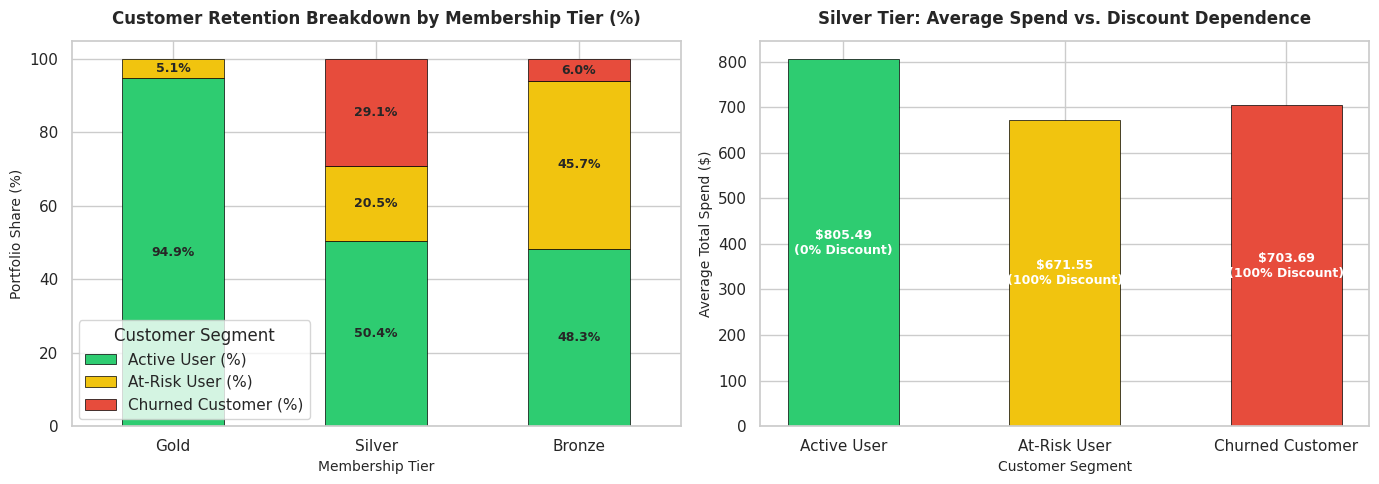

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

counts_data = {
    'Membership Tier': ['Gold', 'Silver', 'Bronze'],
    'Active User (%)': [94.9, 50.4, 48.3],
    'At-Risk User (%)': [5.1, 20.5, 45.7],
    'Churned Customer (%)': [0.0, 29.1, 6.0],
}

df_counts = pd.DataFrame(counts_data).set_index('Membership Tier')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#2ecc71', '#f1c40f', '#e74c3c'],
    edgecolor='black',
    linewidth=0.5,
)
axes[0].set_title(
    'Customer Retention Breakdown by Membership Tier (%)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
axes[0].set_ylabel('Portfolio Share (%)', fontsize=10)
axes[0].set_xlabel('Membership Tier', fontsize=10)
axes[0].legend(title='Customer Segment', frameon=True)
axes[0].tick_params(axis='x', rotation=0)

for c in axes[0].containers:
  labels = [f'{v:.1f}%' if v > 0 else '' for v in c.datavalues]
  axes[0].bar_label(
      c, labels=labels, label_type='center', fontsize=9, fontweight='bold'
  )

silver_summary = pd.DataFrame({
    'Segment': ['Active User', 'At-Risk User', 'Churned Customer'],
    'Total Spend ($)': [805.49, 671.55, 703.69],
    'Discount Rate (%)': [0.0, 100.0, 100.0],
})

x = range(len(silver_summary))
bars = axes[1].bar(
    x,
    silver_summary['Total Spend ($)'],
    color=['#2ecc71', '#f1c40f', '#e74c3c'],
    width=0.5,
    edgecolor='black',
    linewidth=0.5,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(silver_summary['Segment'])
axes[1].set_title(
    'Silver Tier: Average Spend vs. Discount Dependence',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
axes[1].set_ylabel('Average Total Spend ($)', fontsize=10)
axes[1].set_xlabel('Customer Segment', fontsize=10)

for bar, discount in zip(bars, silver_summary['Discount Rate (%)']):
  yval = bar.get_height()
  axes[1].text(
      bar.get_x() + bar.get_width() / 2.0,
      yval / 2,
      f'${yval:.2f}\n({discount:.0f}% Discount)',
      ha='center',
      va='center',
      color='white',
      fontweight='bold',
      fontsize=9,
  )

plt.tight_layout()
plt.show()